# 🛡️ HALT-RAG: Hallucination-Aware Retrieval-Augmented Generation

A complete research-style demo implementing:
- **Experimental retrieval strategies** (Hybrid BM25+FAISS, Dense-only, Two-stage rerank)
- **Lightweight agent workflow** (Planner → Executor → Critic → Logger)
- **Hallucination detection** with classification
- **Structured logging**
- **Evaluation + visualization**

**Runtime:** Google Colab Pro (A100 GPU)  
**Author:** Graduate AI Systems Project  
**License:** MIT  

> ⚠️ This uses a **SYNTHETIC** dataset for evaluation purposes only.

## Section 1: Setup & Installation

Install required packages and verify GPU availability.

In [1]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ SECTION 1: SETUP & INSTALLATION                                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

!pip install -q sentence-transformers faiss-cpu rank-bm25 transformers accelerate matplotlib pandas numpy

import time
import json
import re
import warnings
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Tuple, Optional, Any
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import faiss
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from transformers import pipeline, AutoModelForCausalLM, AutoTokenizer

warnings.filterwarnings("ignore")

print("=" * 70)
print("HALT-RAG: Hallucination-Aware Retrieval-Augmented Generation")
print("=" * 70)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 105.7 MB/s eta 0:00:00
HALT-RAG: Hallucination-Aware Retrieval-Augmented Generation
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB



## Section 2: Synthetic Evaluation Dataset

Create a synthetic evaluation dataset with 55 test cases across multiple domains.

Each test case includes: `id`, `question`, `expected_answer`, `relevant_context`, `domain`, `difficulty`, `expected_hallucination_type`

> **NOTE:** This dataset is SYNTHETIC — created for evaluation purposes only.

In [2]:
print("=" * 70)
print("SECTION 2: Creating Synthetic Evaluation Dataset")
print("=" * 70)
print("NOTE: This dataset is SYNTHETIC — created for evaluation purposes only.")
print()


def create_synthetic_dataset() -> List[Dict]:
    """
    Create a synthetic evaluation dataset with 50+ test cases.
    Each case is designed to test different aspects of RAG + hallucination detection.

    Domains: Science, History, Technology, Medicine, Geography
    Difficulties: easy, medium, hard
    Expected hallucination types: factual, contextual, reasoning, faithful
    """
    dataset = [
        # === SCIENCE DOMAIN (10 cases) ===
        {
            "id": "SCI-001",
            "question": "What is the speed of light in a vacuum?",
            "expected_answer": "The speed of light in a vacuum is approximately 299,792,458 meters per second.",
            "relevant_context": "Light travels at a constant speed in a vacuum, measured precisely at 299,792,458 meters per second (approximately 3 × 10^8 m/s). This is denoted by the constant 'c' and is a fundamental physical constant.",
            "domain": "science",
            "difficulty": "easy",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "SCI-002",
            "question": "What causes the aurora borealis?",
            "expected_answer": "The aurora borealis is caused by charged particles from the sun interacting with gases in Earth's atmosphere.",
            "relevant_context": "The aurora borealis (Northern Lights) occurs when charged particles from the solar wind interact with gases in Earth's upper atmosphere. These particles are guided by Earth's magnetic field toward the poles, where they collide with oxygen and nitrogen atoms, causing them to emit light.",
            "domain": "science",
            "difficulty": "medium",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "SCI-003",
            "question": "How does photosynthesis convert sunlight into energy?",
            "expected_answer": "Photosynthesis uses chlorophyll to absorb sunlight, converting CO2 and water into glucose and oxygen through light-dependent and light-independent reactions.",
            "relevant_context": "Photosynthesis occurs in two stages: light-dependent reactions in the thylakoid membranes capture solar energy using chlorophyll pigments, splitting water molecules and generating ATP and NADPH. The Calvin cycle (light-independent reactions) in the stroma then uses these energy carriers to fix CO2 into glucose (C6H12O6), releasing oxygen as a byproduct.",
            "domain": "science",
            "difficulty": "medium",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "SCI-004",
            "question": "What is the Heisenberg uncertainty principle?",
            "expected_answer": "The Heisenberg uncertainty principle states that it is impossible to simultaneously know both the exact position and exact momentum of a particle.",
            "relevant_context": "The Heisenberg uncertainty principle, formulated by Werner Heisenberg in 1927, establishes a fundamental limit in quantum mechanics. It states that the more precisely the position of a particle is determined, the less precisely its momentum can be known, and vice versa. Mathematically: Δx·Δp ≥ ℏ/2.",
            "domain": "science",
            "difficulty": "hard",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "SCI-005",
            "question": "What temperature does water boil at on Mars?",
            "expected_answer": "Water boils at a much lower temperature on Mars due to the very low atmospheric pressure, roughly around 0-10°C depending on conditions.",
            "relevant_context": "Mars has an atmospheric pressure of about 610 Pascals (0.6% of Earth's sea level pressure). Due to this extremely low pressure, the boiling point of water on Mars is significantly reduced. At typical Martian surface pressures, water would boil at approximately 0-2°C rather than 100°C as on Earth at sea level.",
            "domain": "science",
            "difficulty": "hard",
            "expected_hallucination_type": "contextual",
        },
        {
            "id": "SCI-006",
            "question": "What is CRISPR-Cas9?",
            "expected_answer": "CRISPR-Cas9 is a gene-editing technology that allows precise modification of DNA sequences in living organisms.",
            "relevant_context": "CRISPR-Cas9 is a revolutionary gene-editing tool adapted from a natural defense mechanism in bacteria. The system uses a guide RNA to direct the Cas9 enzyme to a specific location in the genome, where it makes a precise cut in the DNA double helix. This allows researchers to delete, modify, or insert genetic material at targeted locations.",
            "domain": "science",
            "difficulty": "medium",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "SCI-007",
            "question": "How do black holes form?",
            "expected_answer": "Black holes form when massive stars exhaust their nuclear fuel and collapse under their own gravity.",
            "relevant_context": "Stellar black holes form through gravitational collapse when a massive star (typically >25 solar masses) exhausts its nuclear fuel. Without the outward radiation pressure to counteract gravity, the core collapses. If the remaining mass exceeds the Tolman-Oppenheimer-Volkoff limit (~2-3 solar masses), neutron degeneracy pressure cannot halt the collapse, and a black hole forms.",
            "domain": "science",
            "difficulty": "medium",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "SCI-008",
            "question": "What is dark matter made of?",
            "expected_answer": "The composition of dark matter is unknown. Leading candidates include WIMPs and axions, but it has not been directly detected.",
            "relevant_context": "Dark matter constitutes approximately 27% of the universe's mass-energy content, yet its composition remains one of physics' greatest mysteries. It does not emit, absorb, or reflect electromagnetic radiation. Leading theoretical candidates include Weakly Interacting Massive Particles (WIMPs), axions, and sterile neutrinos. Despite numerous detection experiments, dark matter has not been directly observed.",
            "domain": "science",
            "difficulty": "hard",
            "expected_hallucination_type": "reasoning",
        },
        {
            "id": "SCI-009",
            "question": "What is the half-life of carbon-14?",
            "expected_answer": "The half-life of carbon-14 is approximately 5,730 years.",
            "relevant_context": "Carbon-14 (14C) is a radioactive isotope of carbon with a half-life of 5,730 ± 40 years. It is continuously produced in the upper atmosphere by cosmic ray bombardment of nitrogen-14. This predictable decay rate makes it invaluable for radiocarbon dating of organic materials up to about 50,000 years old.",
            "domain": "science",
            "difficulty": "easy",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "SCI-010",
            "question": "Why is the sky blue?",
            "expected_answer": "The sky appears blue because of Rayleigh scattering — shorter blue wavelengths of sunlight are scattered more than longer wavelengths by atmospheric molecules.",
            "relevant_context": "The blue color of the sky is caused by Rayleigh scattering. When sunlight enters Earth's atmosphere, it collides with gas molecules. Since the scattering intensity is inversely proportional to the fourth power of wavelength (1/λ⁴), shorter wavelengths (blue/violet) scatter much more than longer wavelengths (red/orange). Our eyes are more sensitive to blue than violet, so we perceive the sky as blue.",
            "domain": "science",
            "difficulty": "easy",
            "expected_hallucination_type": "faithful",
        },
        # === HISTORY DOMAIN (10 cases) ===
        {
            "id": "HIS-001",
            "question": "When did World War II end?",
            "expected_answer": "World War II ended in 1945, with Germany surrendering in May and Japan in August/September.",
            "relevant_context": "World War II ended in 1945. Germany surrendered unconditionally on May 8, 1945 (V-E Day). Japan announced its surrender on August 15, 1945 (V-J Day), following the atomic bombings of Hiroshima and Nagasaki. The formal surrender was signed on September 2, 1945, aboard the USS Missouri in Tokyo Bay.",
            "domain": "history",
            "difficulty": "easy",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "HIS-002",
            "question": "What caused the fall of the Roman Empire?",
            "expected_answer": "The fall of the Roman Empire was caused by multiple factors including economic troubles, military overextension, barbarian invasions, and political instability.",
            "relevant_context": "Historians attribute the fall of the Western Roman Empire (476 CE) to a complex combination of factors: severe economic troubles and overtaxation, military overextension and reliance on mercenaries, repeated barbarian invasions (Visigoths, Vandals, Huns), political instability with rapid emperor turnover, administrative division, and loss of traditional civic values.",
            "domain": "history",
            "difficulty": "medium",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "HIS-003",
            "question": "Who built the Great Wall of China?",
            "expected_answer": "The Great Wall was built over many centuries by multiple Chinese dynasties, with the most well-known sections constructed during the Ming Dynasty (1368-1644).",
            "relevant_context": "The Great Wall of China was not built by a single ruler but constructed and reconstructed over approximately 2,000 years by multiple dynasties. The earliest walls date to the 7th century BCE. Emperor Qin Shi Huang connected existing walls around 221 BCE. The most recognizable sections were built during the Ming Dynasty (1368-1644 CE), stretching over 8,850 kilometers.",
            "domain": "history",
            "difficulty": "medium",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "HIS-004",
            "question": "What was the significance of the Rosetta Stone?",
            "expected_answer": "The Rosetta Stone was key to deciphering Egyptian hieroglyphics because it contained the same text in three scripts: hieroglyphic, Demotic, and Greek.",
            "relevant_context": "The Rosetta Stone, discovered in 1799 by French soldiers in Egypt, contains a decree issued in 196 BCE written in three scripts: Ancient Egyptian hieroglyphics, Demotic script, and Ancient Greek. Since scholars could read Greek, they could use it as a reference to decode the hieroglyphics. Jean-François Champollion finally deciphered the hieroglyphics in 1822.",
            "domain": "history",
            "difficulty": "medium",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "HIS-005",
            "question": "What year did the first humans land on the Moon?",
            "expected_answer": "The first humans landed on the Moon in 1969 during the Apollo 11 mission.",
            "relevant_context": "On July 20, 1969, NASA's Apollo 11 mission successfully landed the first humans on the Moon. Astronauts Neil Armstrong and Buzz Aldrin walked on the lunar surface while Michael Collins orbited above in the command module. Armstrong's famous words upon stepping onto the surface were 'That's one small step for man, one giant leap for mankind.'",
            "domain": "history",
            "difficulty": "easy",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "HIS-006",
            "question": "What were the main causes of World War I?",
            "expected_answer": "The main causes of WWI include militarism, alliances, imperialism, nationalism, and the assassination of Archduke Franz Ferdinand.",
            "relevant_context": "The causes of World War I are often summarized by the acronym MANIA: Militarism (arms race between European powers), Alliances (complex treaty obligations), Nationalism (ethnic tensions especially in the Balkans), Imperialism (competition for colonies), and the immediate trigger: the Assassination of Archduke Franz Ferdinand of Austria-Hungary on June 28, 1914, in Sarajevo.",
            "domain": "history",
            "difficulty": "medium",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "HIS-007",
            "question": "How did the Black Death spread across Europe?",
            "expected_answer": "The Black Death spread primarily through fleas on rats, traveling along trade routes from Central Asia to Europe via merchant ships.",
            "relevant_context": "The Black Death (1347-1351) spread from Central Asia along the Silk Road trade routes. It reached Europe via merchant ships, notably arriving at the Sicilian port of Messina in October 1347. The plague was caused by Yersinia pestis bacteria, primarily transmitted through bites of infected fleas living on black rats. Crowded medieval cities with poor sanitation facilitated rapid spread, killing 30-60% of Europe's population.",
            "domain": "history",
            "difficulty": "medium",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "HIS-008",
            "question": "What was the exact population of ancient Rome at its peak?",
            "expected_answer": "The exact population is uncertain, but estimates suggest Rome had approximately 1 million inhabitants at its peak around 100-200 CE.",
            "relevant_context": "The population of ancient Rome at its peak is debated among historians. Most estimates suggest the city housed between 800,000 and 1.2 million people during the 1st-2nd centuries CE. Census records exist but are incomplete and their interpretation is contested. The broader Roman Empire may have contained 55-70 million people at its height.",
            "domain": "history",
            "difficulty": "hard",
            "expected_hallucination_type": "reasoning",
        },
        {
            "id": "HIS-009",
            "question": "Who invented the printing press?",
            "expected_answer": "Johannes Gutenberg invented the movable-type printing press around 1440 in Mainz, Germany.",
            "relevant_context": "Johannes Gutenberg is credited with inventing the movable-type printing press in Europe around 1440 in Mainz, Germany. His key innovation was the combination of a hand mold for casting metal type, oil-based ink, and a wooden press adapted from wine/olive presses. His most famous work, the Gutenberg Bible (1455), demonstrated the technology's potential. Note: movable type existed earlier in China (Bi Sheng, 1040 CE) and Korea.",
            "domain": "history",
            "difficulty": "easy",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "HIS-010",
            "question": "What happened at the Battle of Thermopylae?",
            "expected_answer": "At Thermopylae in 480 BCE, a small Greek force led by King Leonidas and 300 Spartans held the narrow pass against the massive Persian army of Xerxes for three days.",
            "relevant_context": "The Battle of Thermopylae (480 BCE) was a famous last stand. King Leonidas I of Sparta, with approximately 300 Spartans and several thousand other Greek allies (estimates of 5,000-7,000 total), held the narrow coastal pass of Thermopylae against Xerxes I's Persian army (estimated 70,000-300,000). They held for three days before being outflanked via a mountain path revealed by a local traitor named Ephialtes.",
            "domain": "history",
            "difficulty": "hard",
            "expected_hallucination_type": "contextual",
        },
        # === TECHNOLOGY DOMAIN (10 cases) ===
        {
            "id": "TECH-001",
            "question": "What is a transformer model in machine learning?",
            "expected_answer": "A transformer is a neural network architecture that uses self-attention mechanisms to process sequential data in parallel, introduced in the 'Attention Is All You Need' paper.",
            "relevant_context": "The Transformer architecture was introduced in the 2017 paper 'Attention Is All You Need' by Vaswani et al. at Google. It uses self-attention mechanisms to process all positions in a sequence simultaneously (in parallel), unlike recurrent models (RNNs/LSTMs) that process sequentially. Key components include multi-head attention, positional encoding, and feed-forward layers. Transformers form the basis of models like BERT, GPT, and T5.",
            "domain": "technology",
            "difficulty": "medium",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "TECH-002",
            "question": "How does blockchain work?",
            "expected_answer": "Blockchain is a distributed ledger that records transactions in linked, cryptographically secured blocks. Each block contains a hash of the previous block, creating an immutable chain.",
            "relevant_context": "A blockchain is a decentralized, distributed digital ledger. Transactions are grouped into blocks, each containing: a cryptographic hash of the previous block, a timestamp, and transaction data. This linking creates a chain where altering any block would invalidate all subsequent blocks. Consensus mechanisms (Proof of Work, Proof of Stake) ensure agreement among network participants without a central authority.",
            "domain": "technology",
            "difficulty": "medium",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "TECH-003",
            "question": "What is quantum computing?",
            "expected_answer": "Quantum computing uses quantum mechanical phenomena like superposition and entanglement to perform computations that are intractable for classical computers.",
            "relevant_context": "Quantum computing harnesses quantum mechanical phenomena to process information. Unlike classical bits (0 or 1), quantum bits (qubits) can exist in superposition (both states simultaneously). Entanglement allows correlated qubits to be linked regardless of distance. These properties enable quantum computers to solve certain problems exponentially faster than classical computers, such as factoring large numbers (Shor's algorithm) and searching unsorted databases (Grover's algorithm).",
            "domain": "technology",
            "difficulty": "hard",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "TECH-004",
            "question": "When was the first iPhone released?",
            "expected_answer": "The first iPhone was released on June 29, 2007.",
            "relevant_context": "The original iPhone was announced by Steve Jobs on January 9, 2007, at the Macworld Conference & Expo, and released on June 29, 2007. It featured a 3.5-inch touchscreen, 2-megapixel camera, and ran iPhone OS 1.0. It was initially exclusive to AT&T in the United States and priced at $499 for the 4GB model and $599 for 8GB.",
            "domain": "technology",
            "difficulty": "easy",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "TECH-005",
            "question": "What is the difference between supervised and unsupervised learning?",
            "expected_answer": "Supervised learning uses labeled data to train models to predict outcomes, while unsupervised learning finds patterns in unlabeled data without predefined targets.",
            "relevant_context": "In machine learning, supervised learning trains models on labeled datasets where each example has an input-output pair. The model learns to map inputs to correct outputs (classification, regression). Unsupervised learning works with unlabeled data, discovering hidden patterns, groupings, or structure (clustering, dimensionality reduction, anomaly detection). Semi-supervised learning combines both approaches.",
            "domain": "technology",
            "difficulty": "easy",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "TECH-006",
            "question": "How does GPT-4 compare to GPT-3 in terms of parameters?",
            "expected_answer": "The exact parameter count of GPT-4 has not been officially disclosed by OpenAI, unlike GPT-3 which has 175 billion parameters.",
            "relevant_context": "GPT-3, released in 2020, contains 175 billion parameters. OpenAI has not officially disclosed the parameter count of GPT-4 (released March 2023). Various rumors and leaks suggest it may use a Mixture of Experts architecture with approximately 1.7 trillion total parameters across 16 experts, but this has not been confirmed by OpenAI. The company has moved away from disclosing model sizes.",
            "domain": "technology",
            "difficulty": "hard",
            "expected_hallucination_type": "reasoning",
        },
        {
            "id": "TECH-007",
            "question": "What programming language is Python named after?",
            "expected_answer": "Python is named after the BBC comedy series 'Monty Python's Flying Circus', not the snake.",
            "relevant_context": "Python was created by Guido van Rossum and first released in 1991. The language is named after the British comedy group Monty Python (specifically their show 'Monty Python's Flying Circus'), not after the snake. Van Rossum was reading scripts from the show while developing the language and wanted a short, unique, and slightly mysterious name.",
            "domain": "technology",
            "difficulty": "easy",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "TECH-008",
            "question": "What is federated learning?",
            "expected_answer": "Federated learning is a machine learning approach where models are trained across decentralized devices holding local data, without exchanging raw data.",
            "relevant_context": "Federated learning is a distributed machine learning approach proposed by Google in 2016. Instead of centralizing training data, the model is sent to devices (phones, hospitals, etc.) where it trains on local data. Only model updates (gradients) are sent back to a central server for aggregation. This preserves data privacy as raw data never leaves the device. Challenges include non-IID data distributions and communication efficiency.",
            "domain": "technology",
            "difficulty": "hard",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "TECH-009",
            "question": "How many transistors are in a modern CPU?",
            "expected_answer": "Modern CPUs contain tens of billions of transistors. For example, Apple's M2 Ultra has about 134 billion transistors.",
            "relevant_context": "Modern processors contain billions of transistors. As of 2023-2024, high-end examples include: Apple M2 Ultra (~134 billion transistors), AMD EPYC Genoa (~90 billion), Intel's Ponte Vecchio GPU (~100 billion). Consumer CPUs like AMD Ryzen 9 7950X contain about 13 billion transistors. Transistor counts have followed Moore's Law for decades, roughly doubling every 2 years.",
            "domain": "technology",
            "difficulty": "medium",
            "expected_hallucination_type": "factual",
        },
        {
            "id": "TECH-010",
            "question": "What is the halting problem?",
            "expected_answer": "The halting problem proves that no general algorithm can determine whether an arbitrary program will eventually halt or run forever.",
            "relevant_context": "The halting problem, proven undecidable by Alan Turing in 1936, states that no general algorithm can determine, for all possible program-input pairs, whether the program will eventually halt (finish) or continue to run forever. This was proven by contradiction: assuming such an algorithm exists leads to a logical paradox. It establishes fundamental limits on what computers can decide.",
            "domain": "technology",
            "difficulty": "hard",
            "expected_hallucination_type": "faithful",
        },
        # === MEDICINE DOMAIN (10 cases) ===
        {
            "id": "MED-001",
            "question": "What is the function of insulin in the human body?",
            "expected_answer": "Insulin regulates blood glucose levels by enabling cells to absorb glucose from the bloodstream for energy or storage.",
            "relevant_context": "Insulin is a peptide hormone produced by beta cells in the pancreatic islets of Langerhans. Its primary function is to regulate blood glucose levels. When blood sugar rises (e.g., after eating), insulin signals cells (especially muscle, fat, and liver cells) to absorb glucose from the bloodstream. It promotes glycogen synthesis in the liver and fat storage in adipose tissue, effectively lowering blood sugar levels.",
            "domain": "medicine",
            "difficulty": "easy",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "MED-002",
            "question": "How do mRNA vaccines work?",
            "expected_answer": "mRNA vaccines deliver synthetic mRNA that instructs cells to produce a harmless piece of the target virus (like the spike protein), triggering an immune response.",
            "relevant_context": "mRNA vaccines contain synthetic messenger RNA encoding instructions for producing a specific viral protein (e.g., SARS-CoV-2 spike protein). Once injected, the mRNA enters cells and is translated by ribosomes into the target protein. The immune system recognizes this protein as foreign, producing antibodies and training T-cells. The mRNA is naturally degraded within days and does not alter DNA, which remains in the nucleus.",
            "domain": "medicine",
            "difficulty": "medium",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "MED-003",
            "question": "What is the difference between Type 1 and Type 2 diabetes?",
            "expected_answer": "Type 1 diabetes is an autoimmune condition where the body destroys insulin-producing cells. Type 2 is characterized by insulin resistance, often linked to lifestyle factors.",
            "relevant_context": "Type 1 diabetes is an autoimmune disease where the immune system destroys pancreatic beta cells, eliminating insulin production. It typically appears in childhood/adolescence and requires lifelong insulin therapy. Type 2 diabetes involves insulin resistance — cells don't respond effectively to insulin — often combined with gradually declining insulin production. It accounts for ~90% of diabetes cases and is associated with obesity, sedentary lifestyle, and genetic factors.",
            "domain": "medicine",
            "difficulty": "medium",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "MED-004",
            "question": "Can aspirin cure cancer?",
            "expected_answer": "Aspirin cannot cure cancer. Some studies suggest it may reduce risk of certain cancers (particularly colorectal), but it is not a cancer treatment.",
            "relevant_context": "Aspirin (acetylsalicylic acid) is a nonsteroidal anti-inflammatory drug (NSAID). Research has shown associations between regular low-dose aspirin use and reduced risk of colorectal cancer (approximately 20-30% reduction in some studies). However, aspirin is NOT a cancer treatment or cure. Its anti-cancer mechanisms likely involve COX-2 inhibition reducing inflammation. Current medical guidance does not recommend aspirin solely for cancer prevention due to bleeding risks.",
            "domain": "medicine",
            "difficulty": "hard",
            "expected_hallucination_type": "factual",
        },
        {
            "id": "MED-005",
            "question": "What is the normal resting heart rate for adults?",
            "expected_answer": "The normal resting heart rate for adults is between 60 and 100 beats per minute.",
            "relevant_context": "A normal resting heart rate for adults ranges from 60 to 100 beats per minute (bpm). Well-trained athletes may have resting rates as low as 40-60 bpm due to more efficient cardiac function. Factors affecting heart rate include age, fitness level, body temperature, medications, stress, and body position. A consistently high resting heart rate (>100 bpm) is called tachycardia.",
            "domain": "medicine",
            "difficulty": "easy",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "MED-006",
            "question": "How does antibiotic resistance develop?",
            "expected_answer": "Antibiotic resistance develops through natural selection — bacteria with random mutations that confer resistance survive antibiotic exposure and reproduce, spreading resistant genes.",
            "relevant_context": "Antibiotic resistance develops through evolutionary pressure. When bacteria are exposed to antibiotics, those with random genetic mutations conferring resistance survive and reproduce (natural selection). Resistance genes can spread through: vertical transfer (parent to offspring), horizontal gene transfer (conjugation, transformation, transduction between bacteria). Overuse and misuse of antibiotics accelerates this process. WHO considers antibiotic resistance one of the biggest threats to global health.",
            "domain": "medicine",
            "difficulty": "medium",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "MED-007",
            "question": "What is the exact cure rate for stage 4 pancreatic cancer?",
            "expected_answer": "Stage 4 pancreatic cancer has an extremely poor prognosis with a 5-year survival rate of approximately 1-3%. There is no guaranteed cure.",
            "relevant_context": "Stage 4 (metastatic) pancreatic cancer has one of the lowest survival rates among cancers. The 5-year survival rate is approximately 1-3%. Median survival after diagnosis is 3-6 months with treatment. Treatments (chemotherapy combinations like FOLFIRINOX, gemcitabine+nab-paclitaxel) can extend survival but rarely achieve complete remission. Clinical trials continue to explore immunotherapy and targeted therapy approaches.",
            "domain": "medicine",
            "difficulty": "hard",
            "expected_hallucination_type": "factual",
        },
        {
            "id": "MED-008",
            "question": "What causes Alzheimer's disease?",
            "expected_answer": "The exact cause of Alzheimer's is not fully understood, but it involves accumulation of amyloid-beta plaques and tau tangles in the brain, along with genetic and environmental factors.",
            "relevant_context": "Alzheimer's disease is a progressive neurodegenerative disorder. Its exact cause remains unclear, but key pathological features include: accumulation of amyloid-beta protein plaques between neurons, formation of neurofibrillary tangles of tau protein inside neurons, chronic neuroinflammation, and synaptic loss. Risk factors include age, genetics (APOE4 allele), cardiovascular health, and possibly environmental factors. The amyloid hypothesis is debated.",
            "domain": "medicine",
            "difficulty": "hard",
            "expected_hallucination_type": "reasoning",
        },
        {
            "id": "MED-009",
            "question": "How long does it take for a broken bone to heal?",
            "expected_answer": "Most broken bones take 6-8 weeks to heal substantially, though complete healing can take months depending on the bone and severity.",
            "relevant_context": "Bone fracture healing time varies by location, severity, and patient factors. General timelines: finger/toe bones: 3-5 weeks; wrist/arm: 6-8 weeks; leg bones: 8-12 weeks; femur: 12-16 weeks. Healing occurs in stages: inflammation (days 1-5), soft callus formation (weeks 1-3), hard callus (weeks 3-8), and remodeling (months to years). Factors affecting healing include age, nutrition, blood supply, and whether the fracture is displaced.",
            "domain": "medicine",
            "difficulty": "easy",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "MED-010",
            "question": "Is there a proven link between vaccines and autism?",
            "expected_answer": "No. Extensive scientific research involving millions of children has found no link between vaccines and autism. The original 1998 study was fraudulent and retracted.",
            "relevant_context": "There is no scientific evidence linking vaccines to autism. The claim originated from a 1998 study by Andrew Wakefield published in The Lancet, which was later found to be fraudulent — the paper was retracted in 2010, and Wakefield lost his medical license. Subsequent studies involving millions of children (including a 2019 Danish study of 657,461 children) have consistently found no association between vaccination and autism spectrum disorder.",
            "domain": "medicine",
            "difficulty": "medium",
            "expected_hallucination_type": "faithful",
        },
        # === GEOGRAPHY DOMAIN (10 cases) ===
        {
            "id": "GEO-001",
            "question": "What is the longest river in the world?",
            "expected_answer": "The Nile River is traditionally considered the longest river at approximately 6,650 km, though some measurements suggest the Amazon may be longer.",
            "relevant_context": "The title of world's longest river is disputed between the Nile and the Amazon. The Nile, flowing through northeastern Africa, is traditionally measured at approximately 6,650 km (4,130 miles). Recent measurements of the Amazon, including its most distant source in Peru, suggest it may be 6,992 km (4,345 miles). The difference depends on how river length is measured (source definition, channel measurement methods).",
            "domain": "geography",
            "difficulty": "medium",
            "expected_hallucination_type": "contextual",
        },
        {
            "id": "GEO-002",
            "question": "What is the capital of Australia?",
            "expected_answer": "The capital of Australia is Canberra, not Sydney or Melbourne.",
            "relevant_context": "The capital of Australia is Canberra, located in the Australian Capital Territory (ACT). It became the capital in 1913 as a compromise between rivals Sydney and Melbourne. Canberra was purpose-built as the capital city, designed by architects Walter Burley Griffin and Marion Mahony Griffin. Despite being the capital, it has a much smaller population (~450,000) than Sydney (~5.3 million) or Melbourne (~5.1 million).",
            "domain": "geography",
            "difficulty": "easy",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "GEO-003",
            "question": "How deep is the Mariana Trench?",
            "expected_answer": "The Mariana Trench reaches approximately 10,994 meters (36,070 feet) at its deepest point, Challenger Deep.",
            "relevant_context": "The Mariana Trench in the western Pacific Ocean is the deepest known location on Earth. Its deepest point, Challenger Deep, has been measured at approximately 10,994 meters (36,070 feet) below sea level, with measurements varying between surveys (±40 meters). It was first sounded in 1875 by HMS Challenger. Only four crewed descents have reached the bottom: Trieste (1960), Deepsea Challenger (2012), Limiting Factor (2019, multiple dives).",
            "domain": "geography",
            "difficulty": "easy",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "GEO-004",
            "question": "Which countries does the Amazon River flow through?",
            "expected_answer": "The Amazon River flows through Peru, Colombia, and Brazil, with tributaries in several other South American countries.",
            "relevant_context": "The Amazon River's main channel flows through three countries: it originates in Peru (Andes Mountains), briefly passes through Colombia, and flows across Brazil to the Atlantic Ocean. Its vast drainage basin (7 million km²) also covers parts of Bolivia, Venezuela, Ecuador, Guyana, Suriname, and French Guiana. The river discharges approximately 209,000 cubic meters per second — more than the next seven largest rivers combined.",
            "domain": "geography",
            "difficulty": "medium",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "GEO-005",
            "question": "What is the smallest country in the world?",
            "expected_answer": "Vatican City is the smallest country in the world by both area (0.44 km²) and population (~800).",
            "relevant_context": "Vatican City (officially Vatican City State) is the smallest internationally recognized independent state by both area and population. Located within Rome, Italy, it covers approximately 0.44 km² (0.17 sq mi) and has a population of about 800. It became independent from Italy through the 1929 Lateran Treaty. The second smallest country is Monaco (2.02 km²).",
            "domain": "geography",
            "difficulty": "easy",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "GEO-006",
            "question": "Why is the Dead Sea called 'dead'?",
            "expected_answer": "The Dead Sea is called 'dead' because its extreme salinity (about 34%) prevents most organisms from living in it.",
            "relevant_context": "The Dead Sea, bordered by Jordan, Israel, and the West Bank, is called 'dead' because its extreme salinity (~34.2%, nearly 10 times saltier than the ocean) prevents macroscopic aquatic organisms from thriving. However, it's not truly lifeless — certain halophilic (salt-loving) bacteria and archaea survive there. Its surface is about 430 meters below sea level, making it Earth's lowest land elevation. The sea has been shrinking due to water diversion from the Jordan River.",
            "domain": "geography",
            "difficulty": "medium",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "GEO-007",
            "question": "How many countries are there in Africa?",
            "expected_answer": "There are 54 recognized sovereign countries in Africa.",
            "relevant_context": "Africa contains 54 internationally recognized sovereign states (as recognized by the United Nations and the African Union). The most recent addition was South Sudan, which gained independence from Sudan in 2011. The largest country by area is Algeria; the most populous is Nigeria (~220 million). Western Sahara's status remains disputed. Africa is the second-largest and second-most populous continent.",
            "domain": "geography",
            "difficulty": "easy",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "GEO-008",
            "question": "What causes earthquakes?",
            "expected_answer": "Earthquakes are caused by sudden release of energy in the Earth's crust, usually due to movement along tectonic plate boundaries or fault lines.",
            "relevant_context": "Earthquakes occur when energy stored in Earth's crust is suddenly released, usually due to movement along geological faults. Tectonic plates constantly move (plate tectonics), and stress accumulates at plate boundaries. When friction is overcome, plates slip suddenly, releasing seismic waves. Most earthquakes occur at plate boundaries: transform (San Andreas), convergent (subduction zones), and divergent boundaries. Intraplate earthquakes can also occur along ancient fault lines.",
            "domain": "geography",
            "difficulty": "medium",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "GEO-009",
            "question": "What is the exact current population of Tokyo?",
            "expected_answer": "Tokyo's population is approximately 14 million in the city proper, or about 37 million in the greater metropolitan area, making it the world's most populous metropolitan area.",
            "relevant_context": "Tokyo's population depends on the boundary definition used. Tokyo Metropolis (administrative boundary) has approximately 14 million residents. The Greater Tokyo Area (Tokyo plus surrounding prefectures of Kanagawa, Saitama, and Chiba) has approximately 37-38 million people, making it the world's largest metropolitan area by population. Population figures change continuously and exact numbers depend on the census year and counting methodology.",
            "domain": "geography",
            "difficulty": "hard",
            "expected_hallucination_type": "contextual",
        },
        {
            "id": "GEO-010",
            "question": "Is Greenland a continent or an island?",
            "expected_answer": "Greenland is classified as an island (the world's largest) rather than a continent, primarily due to convention and its geological relationship to the North American plate.",
            "relevant_context": "Greenland is classified as the world's largest island (approximately 2.166 million km²) rather than a continent. The distinction is somewhat arbitrary — Australia (7.692 million km²) is the smallest continent. The classification depends on tectonic plate structure, geological history, and convention. Greenland sits on the North American tectonic plate and is geologically part of the Canadian Shield. Despite its size, it has only about 56,000 inhabitants, mostly along the coast.",
            "domain": "geography",
            "difficulty": "hard",
            "expected_hallucination_type": "reasoning",
        },
        # === ADDITIONAL CASES FOR DIVERSITY (5 cases) ===
        {
            "id": "MIX-001",
            "question": "What is the meaning of life according to Douglas Adams?",
            "expected_answer": "In Douglas Adams' 'The Hitchhiker's Guide to the Galaxy', the answer to the ultimate question of life, the universe, and everything is 42.",
            "relevant_context": "In Douglas Adams' science fiction series 'The Hitchhiker's Guide to the Galaxy' (1979), a supercomputer named Deep Thought computes for 7.5 million years and determines that the Answer to the Ultimate Question of Life, the Universe, and Everything is simply the number 42. The joke is that the actual Question was never properly defined.",
            "domain": "culture",
            "difficulty": "easy",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "MIX-002",
            "question": "Can humans survive without sleep?",
            "expected_answer": "No. Prolonged sleep deprivation causes severe cognitive impairment and can eventually be fatal. The longest documented case of intentional wakefulness was about 11 days.",
            "relevant_context": "Humans cannot survive indefinitely without sleep. Sleep deprivation causes progressive cognitive decline, hallucinations, immune suppression, and potentially death. The longest scientifically documented period without sleep is approximately 264 hours (11 days) by Randy Gardner in 1964, though he experienced severe cognitive and perceptual disturbances. Fatal familial insomnia (FFI) demonstrates that complete inability to sleep is ultimately lethal.",
            "domain": "biology",
            "difficulty": "medium",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "MIX-003",
            "question": "What is the current world record for the 100m sprint?",
            "expected_answer": "The world record for the 100m sprint is 9.58 seconds, set by Usain Bolt at the 2009 World Championships in Berlin.",
            "relevant_context": "The men's 100 meters world record is 9.58 seconds, set by Jamaican sprinter Usain Bolt on August 16, 2009, at the World Championships in Berlin, Germany. He broke his own previous record of 9.69 seconds from the 2008 Beijing Olympics. The women's record is 10.49 seconds by Florence Griffith-Joyner (1988). Bolt also holds the 200m record (19.19s) set at the same 2009 championships.",
            "domain": "sports",
            "difficulty": "easy",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "MIX-004",
            "question": "How do noise-cancelling headphones work?",
            "expected_answer": "Noise-cancelling headphones use microphones to detect ambient sound and generate an 'anti-noise' signal (inverted phase) that destructively interferes with incoming noise.",
            "relevant_context": "Active noise-cancelling (ANC) headphones work through destructive interference. External microphones capture ambient sound waves. A processor analyzes these waves and generates an 'anti-noise' signal — a sound wave with the same amplitude but inverted phase (180° out of phase). When the anti-noise meets the original noise, they cancel each other out (destructive interference). This works best for consistent, low-frequency sounds (airplane engines, HVAC hum) and less effectively for irregular, high-frequency sounds (speech).",
            "domain": "technology",
            "difficulty": "medium",
            "expected_hallucination_type": "faithful",
        },
        {
            "id": "MIX-005",
            "question": "What would happen if the Earth stopped rotating?",
            "expected_answer": "If Earth suddenly stopped rotating, catastrophic effects would include extreme winds, massive tsunamis, redistribution of oceans toward the poles, and loss of the magnetic field.",
            "relevant_context": "If Earth suddenly stopped rotating, the consequences would be catastrophic: (1) Everything not attached to bedrock would continue moving at rotational speed (~1,670 km/h at equator), causing extreme winds and displacement; (2) Oceans would redistribute toward the poles due to loss of centrifugal force, creating a mega-continent at the equator; (3) Day/night cycles would become ~6 months each; (4) The magnetic field (generated by the rotating liquid core) would likely weaken significantly; (5) Climate would become extreme with one side perpetually heated.",
            "domain": "science",
            "difficulty": "hard",
            "expected_hallucination_type": "reasoning",
        },
    ]

    # Validate dataset
    assert len(dataset) >= 50, f"Dataset has only {len(dataset)} cases (need >= 50)"
    ids = [d["id"] for d in dataset]
    assert len(ids) == len(set(ids)), "Duplicate IDs found"

    return dataset


# Create and summarize dataset
eval_dataset = create_synthetic_dataset()
print(f"✓ Created synthetic dataset with {len(eval_dataset)} test cases")
print(f"  Domains: {Counter(d['domain'] for d in eval_dataset)}")
print(f"  Difficulties: {Counter(d['difficulty'] for d in eval_dataset)}")
print(f"  Hallucination types: {Counter(d['expected_hallucination_type'] for d in eval_dataset)}")
print()


SECTION 2: Creating Synthetic Evaluation Dataset
NOTE: This dataset is SYNTHETIC — created for evaluation purposes only.

✓ Created synthetic dataset with 55 test cases
  Domains: Counter({'science': 11, 'technology': 11, 'history': 10, 'medicine': 10, 'geography': 10, 'culture': 1, 'biology': 1, 'sports': 1})
  Difficulties: Counter({'medium': 22, 'easy': 18, 'hard': 15})
  Hallucination types: Counter({'faithful': 42, 'reasoning': 6, 'contextual': 4, 'factual': 3})



## Section 3: Retrieval Strategies (Controlled Experimentation)

Implement and compare 3 retrieval strategies:
1. **Hybrid:** BM25 + FAISS with Reciprocal Rank Fusion (RRF)
2. **Dense-only:** FAISS semantic search
3. **Two-stage:** FAISS → top-k → rerank with combined scoring

Each returns top-k documents with similarity scores.

In [3]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ SECTION 3: RETRIEVAL STRATEGIES (CONTROLLED EXPERIMENTATION)               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("=" * 70)
print("SECTION 3: Building Retrieval Systems")
print("=" * 70)


class RetrievalSystem:
    """
    Manages the knowledge base and provides multiple retrieval strategies.
    """

    def __init__(self, embedding_model_name: str = "sentence-transformers/all-MiniLM-L6-v2"):
        print(f"  Loading embedding model: {embedding_model_name}")
        self.embedding_model = SentenceTransformer(embedding_model_name)
        self.embedding_dim = 384  # all-MiniLM-L6-v2 dimension

        # Storage
        self.documents: List[str] = []
        self.doc_metadata: List[Dict] = []

        # Indices
        self.faiss_index: Optional[faiss.IndexFlatIP] = None
        self.bm25: Optional[BM25Okapi] = None
        self.embeddings: Optional[np.ndarray] = None

    def build_index(self, documents: List[str], metadata: List[Dict] = None):
        """Build both FAISS and BM25 indices from documents."""
        self.documents = documents
        self.doc_metadata = metadata or [{"idx": i} for i in range(len(documents))]

        # Build FAISS index (dense)
        print("  Building FAISS index...")
        self.embeddings = self.embedding_model.encode(
            documents,
            batch_size=32,
            normalize_embeddings=True,
            convert_to_numpy=True,
            show_progress_bar=False,
        )
        self.faiss_index = faiss.IndexFlatIP(self.embedding_dim)
        self.faiss_index.add(self.embeddings.astype("float32"))

        # Build BM25 index (sparse)
        print("  Building BM25 index...")
        tokenized_corpus = [doc.lower().split() for doc in documents]
        self.bm25 = BM25Okapi(tokenized_corpus)

        print(f"  ✓ Indexed {len(documents)} documents")

    def retrieve_hybrid(self, query: str, k: int = 5, rrf_k: int = 60) -> List[Dict]:
        """
        Strategy 1: Hybrid BM25 + FAISS with Reciprocal Rank Fusion.
        Combines sparse (lexical) and dense (semantic) retrieval.
        """
        # Dense retrieval
        q_emb = self.embedding_model.encode(
            [query], normalize_embeddings=True, convert_to_numpy=True
        ).astype("float32")
        dense_scores, dense_indices = self.faiss_index.search(q_emb, k)
        dense_ranking = dense_indices[0].tolist()
        dense_score_map = {idx: float(score) for idx, score in zip(dense_indices[0], dense_scores[0])}

        # Sparse retrieval
        bm25_scores = self.bm25.get_scores(query.lower().split())
        sparse_ranking = np.argsort(bm25_scores)[::-1][:k].tolist()

        # Reciprocal Rank Fusion
        fused_scores = {}
        for rank, idx in enumerate(dense_ranking):
            if idx >= 0:  # FAISS can return -1 for empty results
                fused_scores[idx] = fused_scores.get(idx, 0) + 1.0 / (rrf_k + rank + 1)
        for rank, idx in enumerate(sparse_ranking):
            fused_scores[idx] = fused_scores.get(idx, 0) + 1.0 / (rrf_k + rank + 1)

        # Sort by fused score
        ranked = sorted(fused_scores.items(), key=lambda x: x[1], reverse=True)[:k]

        results = []
        for idx, fused_score in ranked:
            results.append({
                "document": self.documents[idx],
                "index": idx,
                "score": fused_score,
                "dense_score": dense_score_map.get(idx, 0.0),
                "strategy": "hybrid",
            })
        return results

    def retrieve_dense(self, query: str, k: int = 5) -> List[Dict]:
        """
        Strategy 2: Dense-only retrieval using FAISS (semantic search).
        """
        q_emb = self.embedding_model.encode(
            [query], normalize_embeddings=True, convert_to_numpy=True
        ).astype("float32")
        scores, indices = self.faiss_index.search(q_emb, k)

        results = []
        for idx, score in zip(indices[0], scores[0]):
            if idx >= 0:
                results.append({
                    "document": self.documents[idx],
                    "index": int(idx),
                    "score": float(score),
                    "dense_score": float(score),
                    "strategy": "dense",
                })
        return results

    def retrieve_two_stage(self, query: str, k: int = 5, first_stage_k: int = 20) -> List[Dict]:
        """
        Strategy 3: Two-stage retrieval.
        Stage 1: FAISS retrieves top-k_first candidates.
        Stage 2: Re-rank candidates using cross-encoder-style similarity scoring.
        """
        # Stage 1: Broad FAISS retrieval
        q_emb = self.embedding_model.encode(
            [query], normalize_embeddings=True, convert_to_numpy=True
        ).astype("float32")
        scores, indices = self.faiss_index.search(q_emb, first_stage_k)

        candidates = []
        for idx, score in zip(indices[0], scores[0]):
            if idx >= 0:
                candidates.append((int(idx), float(score)))

        # Stage 2: Re-rank using token overlap + embedding similarity (lightweight cross-encoder proxy)
        query_tokens = set(query.lower().split())
        reranked = []
        for idx, dense_score in candidates:
            doc = self.documents[idx]
            doc_tokens = set(doc.lower().split())

            # Token overlap (Jaccard-like)
            overlap = len(query_tokens & doc_tokens) / max(len(query_tokens | doc_tokens), 1)

            # Combined score: weighted sum of dense similarity and token overlap
            combined_score = 0.7 * dense_score + 0.3 * overlap
            reranked.append((idx, combined_score, dense_score))

        # Sort by combined score
        reranked.sort(key=lambda x: x[1], reverse=True)
        results = []
        for idx, combined_score, dense_score in reranked[:k]:
            results.append({
                "document": self.documents[idx],
                "index": idx,
                "score": combined_score,
                "dense_score": dense_score,
                "strategy": "two_stage",
            })
        return results

    def add_document(self, text: str, metadata: Dict = None):
        """
        Add a new document to the knowledge base (dynamic update).
        Updates both FAISS and BM25 indices.
        """
        self.documents.append(text)
        self.doc_metadata.append(metadata or {"idx": len(self.documents) - 1})

        # Update FAISS
        new_embedding = self.embedding_model.encode(
            [text], normalize_embeddings=True, convert_to_numpy=True
        ).astype("float32")
        self.faiss_index.add(new_embedding)
        self.embeddings = np.vstack([self.embeddings, new_embedding])

        # Rebuild BM25 (BM25Okapi doesn't support incremental updates)
        tokenized_corpus = [doc.lower().split() for doc in self.documents]
        self.bm25 = BM25Okapi(tokenized_corpus)


# Build knowledge base from dataset contexts
print("  Initializing retrieval system...")
retrieval_system = RetrievalSystem()

# Extract all contexts as our knowledge base
knowledge_base = [item["relevant_context"] for item in eval_dataset]
kb_metadata = [{"id": item["id"], "domain": item["domain"]} for item in eval_dataset]
retrieval_system.build_index(knowledge_base, kb_metadata)
print()


SECTION 3: Building Retrieval Systems
  Initializing retrieval system...
  Loading embedding model: sentence-transformers/all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Building FAISS index...
  Building BM25 index...
  ✓ Indexed 55 documents



## Section 4 & 5: RAG Pipeline + Models

**Pipeline:** query → retrieval → generation → verification

**Models:**
1. **Primary:** TinyLlama-1.1B-Chat (lightweight open-source, chat-capable)
2. **Secondary:** DistilGPT2 (very small, fast baseline)
3. **Fallback:** Rule-based extractive generator (always available)

Rules: Answer ONLY from retrieved context. If insufficient context → "I don't know"

In [4]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ SECTION 4 & 5: RAG PIPELINE + MODELS                                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("=" * 70)
print("SECTION 4 & 5: RAG Pipeline + Model Loading")
print("=" * 70)


class GenerationModel:
    """Wrapper for text generation models."""

    def __init__(self, model_name: str, model_type: str = "pipeline"):
        self.model_name = model_name
        self.model_type = model_type
        self.pipe = None
        self.loaded = False

    def load(self):
        """Load the model. Handles failures gracefully."""
        try:
            print(f"  Loading model: {self.model_name}...")
            device = "cuda" if torch.cuda.is_available() else "cpu"
            dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

            self.pipe = pipeline(
                "text-generation",
                model=self.model_name,
                torch_dtype=dtype,
                device_map="auto" if torch.cuda.is_available() else None,
                device=None if torch.cuda.is_available() else device,
            )
            self.loaded = True
            print(f"  ✓ Model loaded: {self.model_name}")
        except Exception as e:
            print(f"  ✗ Failed to load {self.model_name}: {e}")
            self.loaded = False

    def generate(self, prompt: str, max_new_tokens: int = 256) -> str:
        """Generate text from prompt."""
        if not self.loaded:
            return "[MODEL NOT LOADED]"
        try:
            outputs = self.pipe(
                prompt,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                repetition_penalty=1.1,
                return_full_text=False,
                pad_token_id=self.pipe.tokenizer.eos_token_id,
            )
            return outputs[0]["generated_text"].strip()
        except Exception as e:
            return f"[GENERATION ERROR: {e}]"


class SimpleGeneratorFallback:
    """
    Fallback generator that uses extractive summarization from context.
    Does not require GPU — purely rule-based.
    """

    def __init__(self):
        self.model_name = "extractive-fallback"
        self.loaded = True

    def load(self):
        pass

    def generate(self, prompt: str, max_new_tokens: int = 256) -> str:
        """Extract most relevant sentence from context as answer."""
        # Parse context from prompt
        context_start = prompt.find("Context:")
        question_start = prompt.find("Question:")

        if context_start == -1 or question_start == -1:
            return "I don't know based on the provided context."

        context = prompt[context_start + 8:question_start].strip()
        question = prompt[question_start + 9:].strip()

        # Simple extractive approach: find sentence with most keyword overlap
        sentences = [s.strip() for s in context.replace("\n", " ").split(".") if len(s.strip()) > 10]
        if not sentences:
            return "I don't know based on the provided context."

        question_words = set(question.lower().split())
        best_sentence = ""
        best_score = 0

        for sent in sentences:
            sent_words = set(sent.lower().split())
            overlap = len(question_words & sent_words)
            if overlap > best_score:
                best_score = overlap
                best_sentence = sent

        if best_score == 0:
            return "I don't know based on the provided context."

        return best_sentence.strip() + "."


# Initialize models
print()

# Model 1: TinyLlama (lightweight, open-source, chat-capable)
model_primary = GenerationModel("TinyLlama/TinyLlama-1.1B-Chat-v1.0", model_type="pipeline")
model_primary.load()

# Model 2: DistilGPT2 (very small, fast, good for comparison)
model_secondary = GenerationModel("distilgpt2", model_type="pipeline")
model_secondary.load()

# Model 3: Extractive fallback (rule-based, always available)
model_fallback = SimpleGeneratorFallback()

# Collect available models
available_models = []
if model_primary.loaded:
    available_models.append(("TinyLlama-1.1B-Chat", model_primary))
if model_secondary.loaded:
    available_models.append(("DistilGPT2", model_secondary))
available_models.append(("Extractive-Fallback", model_fallback))

print(f"\n  ✓ {len(available_models)} models available: {[m[0] for m in available_models]}")
print()


def build_rag_prompt(question: str, contexts: List[str]) -> str:
    """Build a RAG prompt with retrieved context."""
    context_text = "\n\n".join(contexts)
    prompt = f"""Answer the question using ONLY the context provided below. If the context does not contain enough information to answer the question, respond with "I don't know based on the provided context."

Context:
{context_text}

Question: {question}

Answer:"""
    return prompt


def build_chat_prompt(question: str, contexts: List[str], tokenizer=None) -> str:
    """Build a chat-formatted prompt for chat models."""
    context_text = "\n\n".join(contexts)
    messages = [
        {
            "role": "system",
            "content": "You are a helpful assistant. Answer questions using ONLY the provided context. If the context is insufficient, say 'I don't know based on the provided context.' Be concise and factual.",
        },
        {
            "role": "user",
            "content": f"Context:\n{context_text}\n\nQuestion: {question}",
        },
    ]
    if tokenizer and hasattr(tokenizer, "apply_chat_template"):
        try:
            return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        except Exception:
            pass
    return build_rag_prompt(question, contexts)


SECTION 4 & 5: RAG Pipeline + Model Loading

  Loading model: TinyLlama/TinyLlama-1.1B-Chat-v1.0...


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

  ✓ Model loaded: distilgpt2

  ✓ 3 models available: ['TinyLlama-1.1B-Chat', 'DistilGPT2', 'Extractive-Fallback']



## Section 6: Agent System (Lightweight)

4 agents implemented as simple classes (no external frameworks):

| Agent | Role |
|-------|------|
| **PlannerAgent** | Rule-based step planning (retrieve → generate → verify) |
| **ExecutorAgent** | Executes retrieval and generation, calls tools |
| **CriticAgent** | Evaluates grounding, assigns hallucination type + confidence |
| **LoggingAgent** | Records all system activity with structured prefixes |

In [5]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ SECTION 6: AGENT SYSTEM (LIGHTWEIGHT)                                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("=" * 70)
print("SECTION 6: Agent System")
print("=" * 70)


class LoggingAgent:
    """
    Records all system activity for analysis.
    Provides structured logging with prefixed messages.
    """

    def __init__(self):
        self.logs: List[Dict] = []

    def log(self, agent: str, action: str, details: Dict = None):
        """Log an agent action with timestamp."""
        entry = {
            "timestamp": time.time(),
            "agent": agent,
            "action": action,
            "details": details or {},
        }
        self.logs.append(entry)
        prefix = f"[{agent.upper()}]"
        print(f"  {prefix:12s} {action}")

    def get_logs(self) -> List[Dict]:
        """Return all logs."""
        return self.logs

    def get_summary(self) -> Dict:
        """Return summary statistics."""
        return {
            "total_entries": len(self.logs),
            "by_agent": Counter(log["agent"] for log in self.logs),
            "by_action": Counter(log["action"] for log in self.logs),
        }

    def clear(self):
        """Clear all logs."""
        self.logs = []


class PlannerAgent:
    """
    Rule-based planner that decides the execution steps.
    Analyzes the query and determines the optimal workflow.
    """

    def __init__(self, logger: LoggingAgent):
        self.logger = logger

    def plan(self, query: str, retrieval_strategy: str = "hybrid") -> List[Dict]:
        """
        Create an execution plan based on the query.
        Returns ordered list of steps.
        """
        self.logger.log("PLANNER", "Planning started", {"query": query[:80]})

        steps = [
            {"step": 1, "action": "retrieve", "strategy": retrieval_strategy, "k": 5},
            {"step": 2, "action": "generate", "model": "primary"},
            {"step": 3, "action": "verify", "checks": ["grounding", "confidence"]},
        ]

        # Adaptive planning based on query complexity
        query_words = query.split()
        if len(query_words) > 15 or "?" in query and query.count("?") > 1:
            # Complex query: add extra retrieval
            steps[0]["k"] = 7
            self.logger.log("PLANNER", "Complex query detected — increased k to 7")

        if any(word in query.lower() for word in ["exact", "precise", "specific", "how many"]):
            # Precision-required query: add stricter verification
            steps[2]["checks"].append("precision_check")
            self.logger.log("PLANNER", "Precision query — added strict verification")

        self.logger.log("PLANNER", f"Plan created: {len(steps)} steps", {"steps": steps})
        return steps


class ExecutorAgent:
    """
    Executes retrieval and generation steps from the plan.
    Calls tools and manages the pipeline execution.
    """

    def __init__(self, retrieval_system: RetrievalSystem, models: List[tuple], logger: LoggingAgent):
        self.retrieval_system = retrieval_system
        self.models = {name: model for name, model in models}
        self.logger = logger

    def execute(self, plan: List[Dict], query: str) -> Dict:
        """Execute the plan and return results."""
        result = {"query": query, "steps_executed": []}

        for step in plan:
            action = step["action"]
            start_time = time.time()

            if action == "retrieve":
                retrieved = self._execute_retrieval(query, step["strategy"], step.get("k", 5))
                result["retrieved_docs"] = retrieved
                result["retrieval_strategy"] = step["strategy"]

            elif action == "generate":
                contexts = [doc["document"] for doc in result.get("retrieved_docs", [])]
                answer = self._execute_generation(query, contexts)
                result["generated_answer"] = answer

            elif action == "verify":
                # Verification handled by CriticAgent
                pass

            elapsed = time.time() - start_time
            result["steps_executed"].append({"action": action, "latency": elapsed})
            self.logger.log("EXECUTOR", f"Step '{action}' completed", {"latency_ms": round(elapsed * 1000, 1)})

        return result

    def _execute_retrieval(self, query: str, strategy: str, k: int) -> List[Dict]:
        """Execute retrieval using specified strategy."""
        self.logger.log("EXECUTOR", f"Retrieving with strategy='{strategy}', k={k}")

        if strategy == "hybrid":
            return self.retrieval_system.retrieve_hybrid(query, k=k)
        elif strategy == "dense":
            return self.retrieval_system.retrieve_dense(query, k=k)
        elif strategy == "two_stage":
            return self.retrieval_system.retrieve_two_stage(query, k=k)
        else:
            self.logger.log("EXECUTOR", f"Unknown strategy '{strategy}', falling back to hybrid")
            return self.retrieval_system.retrieve_hybrid(query, k=k)

    def _execute_generation(self, query: str, contexts: List[str]) -> str:
        """Generate answer using the best available model."""
        if not contexts:
            return "I don't know based on the provided context."

        # Use primary model with chat template if available
        model_name, model = available_models[0]

        if hasattr(model, "pipe") and model.pipe and hasattr(model.pipe, "tokenizer"):
            prompt = build_chat_prompt(query, contexts, model.pipe.tokenizer)
        else:
            prompt = build_rag_prompt(query, contexts)

        answer = model.generate(prompt, max_new_tokens=200)
        self.logger.log("EXECUTOR", f"Generated answer using {model_name}", {"answer_length": len(answer)})
        return answer


class CriticAgent:
    """
    Evaluates answer quality, grounding, and hallucination.
    Assigns hallucination type and confidence score.
    """

    def __init__(self, logger: LoggingAgent):
        self.logger = logger

    def evaluate(self, query: str, answer: str, contexts: List[str]) -> Dict:
        """
        Evaluate the generated answer against retrieved context.
        Returns grounding assessment, hallucination classification, and confidence.
        """
        self.logger.log("CRITIC", "Evaluating answer quality")

        # Compute context overlap
        overlap_score = self._compute_context_overlap(answer, contexts)

        # Grounding check
        grounding = self._check_grounding(answer, contexts)

        # Hallucination classification
        hallucination_type = self._classify_hallucination(answer, contexts, overlap_score)

        # Confidence score (heuristic)
        confidence = self._compute_confidence(overlap_score, grounding, answer)

        evaluation = {
            "context_overlap_score": overlap_score,
            "grounding": grounding,
            "hallucination_type": hallucination_type,
            "confidence_score": confidence,
        }

        self.logger.log("CRITIC", f"Evaluation complete", {
            "overlap": round(overlap_score, 3),
            "confidence": round(confidence, 3),
            "hallucination": hallucination_type,
        })

        return evaluation

    def _compute_context_overlap(self, answer: str, contexts: List[str]) -> float:
        """Compute token-level overlap between answer and contexts."""
        if not answer or not contexts:
            return 0.0

        answer_tokens = set(answer.lower().split())
        context_tokens = set()
        for ctx in contexts:
            context_tokens.update(ctx.lower().split())

        # Remove common stopwords for meaningful overlap
        stopwords = {"the", "a", "an", "is", "are", "was", "were", "in", "on", "at", "to",
                     "for", "of", "and", "or", "it", "its", "this", "that", "with", "by",
                     "from", "as", "be", "has", "had", "have", "not", "but", "if", "they"}

        answer_meaningful = answer_tokens - stopwords
        context_meaningful = context_tokens - stopwords

        if not answer_meaningful:
            return 0.0

        overlap = len(answer_meaningful & context_meaningful) / len(answer_meaningful)
        return overlap

    def _check_grounding(self, answer: str, contexts: List[str]) -> Dict:
        """Check if key claims in the answer are grounded in context."""
        if not answer or not contexts:
            return {"grounded": False, "coverage": 0.0}

        combined_context = " ".join(contexts).lower()
        answer_sentences = [s.strip() for s in answer.split(".") if len(s.strip()) > 5]

        grounded_count = 0
        for sent in answer_sentences:
            # Check if key words from sentence appear in context
            sent_words = set(sent.lower().split()) - {"the", "a", "an", "is", "are", "was", "it"}
            if len(sent_words) == 0:
                continue
            context_words = set(combined_context.split())
            match_ratio = len(sent_words & context_words) / len(sent_words)
            if match_ratio > 0.5:
                grounded_count += 1

        coverage = grounded_count / max(len(answer_sentences), 1)
        return {"grounded": coverage > 0.6, "coverage": coverage}

    def _classify_hallucination(self, answer: str, contexts: List[str], overlap: float) -> str:
        """
        Classify the type of potential hallucination.
        Categories: factual, contextual, reasoning, faithful
        """
        if overlap > 0.7:
            return "faithful"
        elif overlap > 0.5:
            # Partially grounded — check if it's contextual or reasoning
            if any(word in answer.lower() for word in ["because", "therefore", "thus", "since", "implies"]):
                return "reasoning"
            else:
                return "contextual"
        elif overlap > 0.3:
            return "contextual"
        else:
            return "factual"

    def _compute_confidence(self, overlap: float, grounding: Dict, answer: str) -> float:
        """
        Compute a heuristic confidence score [0, 1].
        Higher = more likely to be correct and grounded.
        """
        # Base confidence from overlap
        conf = overlap * 0.5

        # Bonus for grounding
        if grounding.get("grounded", False):
            conf += 0.3
        else:
            conf += grounding.get("coverage", 0) * 0.2

        # Penalty for "I don't know" (but it's actually good behavior)
        if "i don't know" in answer.lower() or "don't know" in answer.lower():
            conf = 0.8  # High confidence in abstention

        # Penalty for very long answers (more likely to hallucinate)
        if len(answer.split()) > 100:
            conf *= 0.9

        # Penalty for very short answers
        if len(answer.split()) < 3:
            conf *= 0.7

        return min(max(conf, 0.0), 1.0)


# Initialize agents
logger_agent = LoggingAgent()
planner_agent = PlannerAgent(logger_agent)
executor_agent = ExecutorAgent(retrieval_system, available_models, logger_agent)
critic_agent = CriticAgent(logger_agent)

print("  ✓ Agent system initialized:")
print("    - PlannerAgent (rule-based step planning)")
print("    - ExecutorAgent (retrieval + generation)")
print("    - CriticAgent (grounding + hallucination detection)")
print("    - LoggingAgent (structured activity recording)")
print()


SECTION 6: Agent System
  ✓ Agent system initialized:
    - PlannerAgent (rule-based step planning)
    - ExecutorAgent (retrieval + generation)
    - CriticAgent (grounding + hallucination detection)
    - LoggingAgent (structured activity recording)



## Section 7: Tools

Callable tool classes:
1. **RetrievalTool** — multi-strategy document retrieval
2. **VerificationTool** — answer grounding verification
3. **KeywordSearchTool** — simple keyword lookup in knowledge base

In [6]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ SECTION 7: TOOLS                                                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("=" * 70)
print("SECTION 7: Tools")
print("=" * 70)


class RetrievalTool:
    """Tool for document retrieval with configurable strategy."""

    name = "retrieval_tool"
    description = "Retrieves relevant documents from the knowledge base."

    def __init__(self, retrieval_system: RetrievalSystem):
        self.retrieval_system = retrieval_system

    def __call__(self, query: str, strategy: str = "hybrid", k: int = 5) -> List[Dict]:
        """Execute retrieval."""
        if strategy == "hybrid":
            return self.retrieval_system.retrieve_hybrid(query, k)
        elif strategy == "dense":
            return self.retrieval_system.retrieve_dense(query, k)
        elif strategy == "two_stage":
            return self.retrieval_system.retrieve_two_stage(query, k)
        return self.retrieval_system.retrieve_hybrid(query, k)


class VerificationTool:
    """Tool for verifying answer grounding against context."""

    name = "verification_tool"
    description = "Verifies if an answer is grounded in the provided context."

    def __call__(self, answer: str, contexts: List[str]) -> Dict:
        """Verify answer grounding."""
        if not answer or not contexts:
            return {"verified": False, "reason": "Empty answer or context"}

        # Token overlap check
        answer_tokens = set(answer.lower().split())
        context_tokens = set()
        for ctx in contexts:
            context_tokens.update(ctx.lower().split())

        stopwords = {"the", "a", "an", "is", "are", "was", "were", "in", "on", "at",
                     "to", "for", "of", "and", "or", "it", "this", "that", "with"}
        answer_meaningful = answer_tokens - stopwords
        context_meaningful = context_tokens - stopwords

        if not answer_meaningful:
            return {"verified": False, "reason": "No meaningful tokens in answer"}

        overlap = len(answer_meaningful & context_meaningful) / len(answer_meaningful)
        unsupported = answer_meaningful - context_meaningful

        return {
            "verified": overlap > 0.5,
            "overlap_score": round(overlap, 4),
            "unsupported_tokens": list(unsupported)[:10],
            "reason": "Sufficient grounding" if overlap > 0.5 else "Insufficient grounding",
        }


class KeywordSearchTool:
    """Simple keyword search tool for quick lookups."""

    name = "keyword_search_tool"
    description = "Searches for specific keywords in the knowledge base."

    def __init__(self, documents: List[str]):
        self.documents = documents

    def __call__(self, keyword: str) -> List[Dict]:
        """Find documents containing the keyword."""
        results = []
        keyword_lower = keyword.lower()
        for i, doc in enumerate(self.documents):
            if keyword_lower in doc.lower():
                results.append({
                    "index": i,
                    "document": doc,
                    "keyword_count": doc.lower().count(keyword_lower),
                })
        return sorted(results, key=lambda x: x["keyword_count"], reverse=True)[:5]


# Initialize tools
retrieval_tool = RetrievalTool(retrieval_system)
verification_tool = VerificationTool()
keyword_tool = KeywordSearchTool(knowledge_base)

print("  ✓ Tools initialized:")
print("    - RetrievalTool (multi-strategy document retrieval)")
print("    - VerificationTool (answer grounding verification)")
print("    - KeywordSearchTool (simple keyword lookup)")
print()


SECTION 7: Tools
  ✓ Tools initialized:
    - RetrievalTool (multi-strategy document retrieval)
    - VerificationTool (answer grounding verification)
    - KeywordSearchTool (simple keyword lookup)



## Section 8: Hallucination Detection

Multi-signal hallucination detector combining:
- Context overlap score (token-level)
- Grounding check (sentence-level)
- Semantic similarity (embedding-based)
- Factual consistency indicators (numbers, entities)

**Classifications:** `faithful`, `factual`, `contextual`, `reasoning`

Also computes a heuristic **confidence score** ∈ [0, 1].

In [7]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ SECTION 8: HALLUCINATION DETECTION                                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("=" * 70)
print("SECTION 8: Hallucination Detection")
print("=" * 70)


class HallucinationDetector:
    """
    Multi-signal hallucination detector.
    Combines context overlap, grounding checks, and optional LLM-as-judge.
    """

    def __init__(self, embedding_model: SentenceTransformer = None):
        self.embedding_model = embedding_model

    def detect(self, answer: str, contexts: List[str], query: str = "") -> Dict:
        """
        Run hallucination detection pipeline.
        Returns classification, confidence, and detailed signals.
        """
        signals = {}

        # Signal 1: Context overlap score
        signals["context_overlap"] = self._context_overlap(answer, contexts)

        # Signal 2: Grounding check (sentence-level)
        signals["grounding"] = self._grounding_check(answer, contexts)

        # Signal 3: Semantic similarity (if embedding model available)
        if self.embedding_model:
            signals["semantic_similarity"] = self._semantic_similarity(answer, contexts)

        # Signal 4: Factual consistency indicators
        signals["factual_indicators"] = self._factual_indicators(answer, contexts)

        # Aggregate signals into classification
        classification = self._classify(signals)

        return {
            "classification": classification["type"],
            "confidence": classification["confidence"],
            "signals": signals,
            "is_hallucination": classification["type"] != "faithful",
        }

    def _context_overlap(self, answer: str, contexts: List[str]) -> float:
        """Token-level overlap between answer and context."""
        if not answer or not contexts:
            return 0.0

        answer_tokens = set(answer.lower().split())
        context_tokens = set()
        for ctx in contexts:
            context_tokens.update(ctx.lower().split())

        stopwords = {"the", "a", "an", "is", "are", "was", "were", "in", "on", "at",
                     "to", "for", "of", "and", "or", "it", "its", "this", "that",
                     "with", "by", "from", "as", "be", "has", "had", "have"}
        answer_meaningful = answer_tokens - stopwords
        context_meaningful = context_tokens - stopwords

        if not answer_meaningful:
            return 0.5  # Neutral if no meaningful tokens

        return len(answer_meaningful & context_meaningful) / len(answer_meaningful)

    def _grounding_check(self, answer: str, contexts: List[str]) -> Dict:
        """Sentence-level grounding assessment."""
        combined = " ".join(contexts).lower()
        sentences = [s.strip() for s in answer.split(".") if len(s.strip()) > 5]

        if not sentences:
            return {"grounded_ratio": 0.0, "total_sentences": 0}

        grounded = 0
        for sent in sentences:
            words = set(sent.lower().split())
            meaningful = words - {"the", "a", "is", "are", "was", "it", "this", "that", "an"}
            if not meaningful:
                grounded += 1
                continue
            ctx_words = set(combined.split())
            ratio = len(meaningful & ctx_words) / len(meaningful)
            if ratio > 0.4:
                grounded += 1

        return {
            "grounded_ratio": grounded / len(sentences),
            "total_sentences": len(sentences),
            "grounded_sentences": grounded,
        }

    def _semantic_similarity(self, answer: str, contexts: List[str]) -> float:
        """Compute semantic similarity between answer and context."""
        if not self.embedding_model or not contexts:
            return 0.0

        answer_emb = self.embedding_model.encode([answer], normalize_embeddings=True)
        context_emb = self.embedding_model.encode(
            [" ".join(contexts)], normalize_embeddings=True
        )
        similarity = float(np.dot(answer_emb[0], context_emb[0]))
        return similarity

    def _factual_indicators(self, answer: str, contexts: List[str]) -> Dict:
        """Check for factual consistency indicators."""
        answer_lower = answer.lower()
        combined_context = " ".join(contexts).lower()

        # Check for numbers in answer that aren't in context
        import re
        answer_numbers = set(re.findall(r'\b\d+\.?\d*\b', answer_lower))
        context_numbers = set(re.findall(r'\b\d+\.?\d*\b', combined_context))
        unsupported_numbers = answer_numbers - context_numbers

        # Check for proper nouns (capitalized words) not in context
        answer_caps = set(re.findall(r'\b[A-Z][a-z]+\b', answer))
        context_caps = set(re.findall(r'\b[A-Z][a-z]+\b', " ".join(contexts)))
        unsupported_entities = answer_caps - context_caps

        return {
            "unsupported_numbers": list(unsupported_numbers),
            "unsupported_entities": list(unsupported_entities)[:5],
            "has_unsupported_facts": len(unsupported_numbers) > 0 or len(unsupported_entities) > 2,
        }

    def _classify(self, signals: Dict) -> Dict:
        """Classify hallucination type based on aggregated signals."""
        overlap = signals.get("context_overlap", 0)
        grounding = signals.get("grounding", {}).get("grounded_ratio", 0)
        semantic_sim = signals.get("semantic_similarity", overlap)  # fallback
        has_unsupported = signals.get("factual_indicators", {}).get("has_unsupported_facts", False)

        # Weighted confidence
        confidence = (0.3 * overlap + 0.3 * grounding + 0.2 * semantic_sim + 0.2 * (0.0 if has_unsupported else 1.0))

        # Classification logic
        if confidence > 0.7:
            return {"type": "faithful", "confidence": confidence}
        elif has_unsupported and overlap < 0.4:
            return {"type": "factual", "confidence": confidence}
        elif grounding < 0.4:
            return {"type": "contextual", "confidence": confidence}
        else:
            return {"type": "reasoning", "confidence": confidence}


# Initialize detector
hallucination_detector = HallucinationDetector(embedding_model=retrieval_system.embedding_model)
print("  ✓ Hallucination detector initialized")
print("    Signals: context_overlap, grounding_check, semantic_similarity, factual_indicators")
print("    Classifications: faithful, factual, contextual, reasoning")
print()


SECTION 8: Hallucination Detection
  ✓ Hallucination detector initialized
    Signals: context_overlap, grounding_check, semantic_similarity, factual_indicators
    Classifications: faithful, factual, contextual, reasoning



## Section 9: Logging Agent Demo

Demonstrates structured logging with `[PLANNER]`, `[EXECUTOR]`, `[CRITIC]`, `[LOG]` prefixes.  
All logs stored in `logger_agent.get_logs()` for later evaluation.

In [8]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ SECTION 9: LOGGING AGENT (STRUCTURED LOGGING)                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# LoggingAgent already defined in Section 6.
# Here we demonstrate its structured output.

print("=" * 70)
print("SECTION 9: Logging Agent Demo")
print("=" * 70)
print()

# Quick demo of the logging system
logger_agent.log("LOG", "System initialized", {"models": len(available_models), "kb_size": len(knowledge_base)})
logger_agent.log("LOG", "Ready for evaluation")
print()


SECTION 9: Logging Agent Demo

  [LOG]        System initialized
  [LOG]        Ready for evaluation



## Section 10: Dynamic Knowledge Update

Demonstrates adding new documents to the knowledge base at runtime.

The `add_new_document()` function:
- Chunks text into ~3-sentence segments
- Generates embeddings
- Updates FAISS index
- Rebuilds BM25 index

> ⚠️ **The model is NOT retrained. Only the retrieval knowledge base is updated.**

In [9]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ SECTION 10: DYNAMIC KNOWLEDGE UPDATE                                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("=" * 70)
print("SECTION 10: Dynamic Knowledge Update")
print("=" * 70)
print()
print("NOTE: The model is NOT retrained. Only the retrieval knowledge base is updated.")
print()


def add_new_document(text: str, retrieval_sys: RetrievalSystem = None):
    """
    Add a new document to the knowledge base.
    Chunks the text, generates embeddings, and updates both FAISS and BM25.

    NOTE: The model is not retrained. Only the retrieval knowledge base is updated.
    """
    if retrieval_sys is None:
        retrieval_sys = retrieval_system

    # Simple chunking: split by sentences, group into chunks of ~3 sentences
    sentences = [s.strip() for s in text.replace("\n", " ").split(".") if len(s.strip()) > 10]

    chunks = []
    chunk_size = 3
    for i in range(0, len(sentences), chunk_size):
        chunk = ". ".join(sentences[i:i + chunk_size]) + "."
        chunks.append(chunk)

    if not chunks:
        chunks = [text]

    # Add each chunk to the retrieval system
    for chunk in chunks:
        retrieval_sys.add_document(chunk, metadata={"source": "dynamic_update"})

    print(f"  ✓ Added {len(chunks)} chunk(s) to knowledge base")
    print(f"  ✓ Knowledge base size: {len(retrieval_sys.documents)} documents")
    return chunks


# Demonstrate dynamic knowledge update
demo_text = """
Large Language Models (LLMs) are neural networks with billions of parameters trained on massive
text corpora. Recent advances include mixture-of-experts architectures, which route different
inputs to specialized sub-networks. This allows scaling model capacity without proportionally
increasing compute costs. Models like Mixtral use 8 experts with a router that selects 2 experts
per token, achieving strong performance with lower inference cost than dense models of similar
total parameter count.
"""

print("  Adding new document about LLMs and Mixture of Experts...")
new_chunks = add_new_document(demo_text)
print()

# Test retrieval after update
test_results = retrieval_tool("What is mixture of experts in LLMs?", strategy="hybrid", k=3)
if test_results:
    print(f"  ✓ Verification: retrieved {len(test_results)} docs for MoE query")
    print(f"    Top result score: {test_results[0]['score']:.4f}")
print()


SECTION 10: Dynamic Knowledge Update

NOTE: The model is NOT retrained. Only the retrieval knowledge base is updated.

  Adding new document about LLMs and Mixture of Experts...
  ✓ Added 2 chunk(s) to knowledge base
  ✓ Knowledge base size: 57 documents

  ✓ Verification: retrieved 3 docs for MoE query
    Top result score: 0.0323



## Section 11: Full Evaluation Loop

Runs the complete pipeline over all 55 queries × 3 retrieval strategies × 3 models.

Collects per-run: retrieval score, context overlap, answer length, hallucination type, confidence, latency.

In [10]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ SECTION 11: EVALUATION LOOP                                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("=" * 70)
print("SECTION 11: Full Evaluation Loop")
print("=" * 70)
print()

# Clear logs for evaluation
logger_agent.clear()


def run_full_pipeline(
    question: str,
    retrieval_strategy: str,
    model_tuple: tuple,
    retrieval_sys: RetrievalSystem,
    detector: HallucinationDetector,
    logger: LoggingAgent,
) -> Dict:
    """
    Run the complete RAG pipeline for a single query.
    Returns all metrics for evaluation.
    """
    start_time = time.time()
    model_name, model = model_tuple

    # Step 1: Plan
    plan = planner_agent.plan(question, retrieval_strategy)

    # Step 2: Retrieve
    if retrieval_strategy == "hybrid":
        retrieved = retrieval_sys.retrieve_hybrid(question, k=5)
    elif retrieval_strategy == "dense":
        retrieved = retrieval_sys.retrieve_dense(question, k=5)
    elif retrieval_strategy == "two_stage":
        retrieved = retrieval_sys.retrieve_two_stage(question, k=5)
    else:
        retrieved = retrieval_sys.retrieve_hybrid(question, k=5)

    contexts = [doc["document"] for doc in retrieved]
    retrieval_score = np.mean([doc["score"] for doc in retrieved]) if retrieved else 0.0

    # Step 3: Generate
    if hasattr(model, "pipe") and model.pipe and hasattr(model.pipe, "tokenizer"):
        prompt = build_chat_prompt(question, contexts, model.pipe.tokenizer)
    else:
        prompt = build_rag_prompt(question, contexts)

    answer = model.generate(prompt, max_new_tokens=200)

    # Step 4: Detect hallucination
    detection = detector.detect(answer, contexts, question)

    # Step 5: Compute metrics
    total_latency = time.time() - start_time

    result = {
        "question": question,
        "retrieval_strategy": retrieval_strategy,
        "model_name": model_name,
        "retrieved_docs": contexts[:3],  # Store top 3 for logging
        "retrieval_score": retrieval_score,
        "generated_answer": answer,
        "context_overlap": detection["signals"]["context_overlap"],
        "answer_length": len(answer.split()),
        "hallucination_type": detection["classification"],
        "confidence_score": detection["confidence"],
        "is_hallucination": detection["is_hallucination"],
        "latency": total_latency,
    }

    # Log the result
    logger.log("LOG", f"Pipeline complete: {retrieval_strategy}/{model_name}", {
        "hallucination": detection["classification"],
        "confidence": round(detection["confidence"], 3),
        "latency_s": round(total_latency, 3),
    })

    return result


# Run evaluation
strategies = ["hybrid", "dense", "two_stage"]
all_results = []

print(f"Running evaluation: {len(eval_dataset)} queries × {len(strategies)} strategies × {len(available_models)} models")
print(f"Total runs: {len(eval_dataset) * len(strategies) * len(available_models)}")
print()

# Limit detailed logging during bulk evaluation
original_log = logger_agent.log


def quiet_log(agent, action, details=None):
    """Quiet logging during bulk eval (no print)."""
    entry = {
        "timestamp": time.time(),
        "agent": agent,
        "action": action,
        "details": details or {},
    }
    logger_agent.logs.append(entry)


logger_agent.log = quiet_log  # Suppress prints during bulk eval

eval_count = 0
total_runs = len(eval_dataset) * len(strategies) * len(available_models)

for strategy in strategies:
    for model_tuple in available_models:
        model_name = model_tuple[0]
        for item in eval_dataset:
            result = run_full_pipeline(
                question=item["question"],
                retrieval_strategy=strategy,
                model_tuple=model_tuple,
                retrieval_sys=retrieval_system,
                detector=hallucination_detector,
                logger=logger_agent,
            )
            result["test_id"] = item["id"]
            result["domain"] = item["domain"]
            result["difficulty"] = item["difficulty"]
            result["expected_hallucination_type"] = item["expected_hallucination_type"]
            all_results.append(result)

            eval_count += 1
            if eval_count % 50 == 0:
                print(f"  Progress: {eval_count}/{total_runs} ({100*eval_count/total_runs:.0f}%)")

# Restore logging
logger_agent.log = original_log

print(f"\n  ✓ Evaluation complete: {len(all_results)} total results")
print()

# Convert to DataFrame for analysis
results_df = pd.DataFrame(all_results)


SECTION 11: Full Evaluation Loop

Running evaluation: 55 queries × 3 strategies × 3 models
Total runs: 495



The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'repetition_penalty', 'max_new_tokens', 'do_sample', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to hav

  Progress: 50/495 (10%)


Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  Progress: 100/495 (20%)


...

  Progress: 350/495 (71%)


Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  Progress: 400/495 (81%)


Both `max_new_tokens` (=200) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

  Progress: 450/495 (91%)

  ✓ Evaluation complete: 495 total results



## Section 12: Evaluation Plots (Matplotlib)

6 plots generated:
1. Hallucination type distribution
2. Confidence score histogram
3. Retrieval strategy vs hallucination rate
4. Retrieval strategy vs latency
5. Model comparison (hallucination rate)
6. Average confidence by domain

SECTION 12: Generating Plots



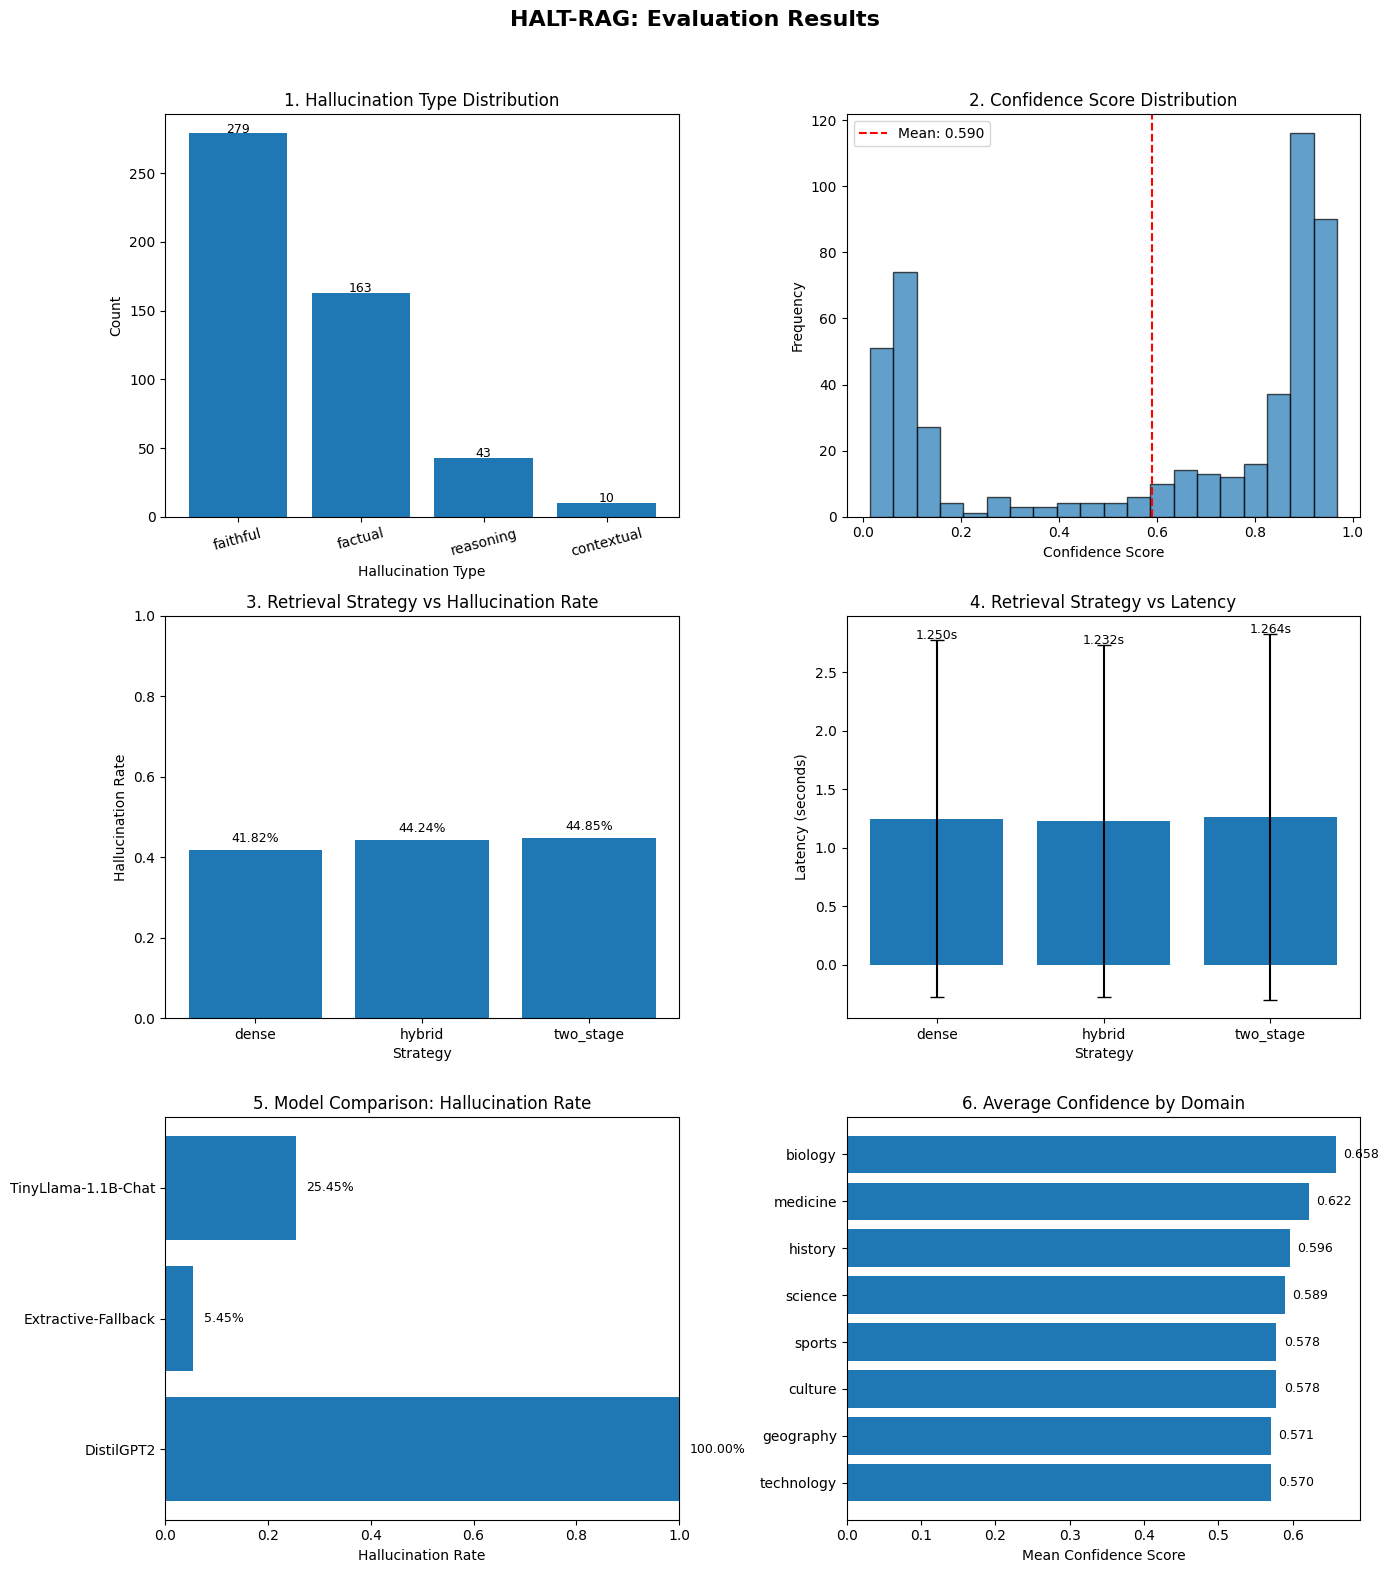

  ✓ Plots saved to 'halt_rag_results.png'



In [11]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ SECTION 12: PLOTS (MATPLOTLIB ONLY)                                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("=" * 70)
print("SECTION 12: Generating Plots")
print("=" * 70)
print()

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle("HALT-RAG: Evaluation Results", fontsize=16, fontweight="bold", y=0.98)

# Plot 1: Hallucination Type Distribution
ax = axes[0, 0]
hall_counts = results_df["hallucination_type"].value_counts()
ax.bar(hall_counts.index, hall_counts.values)
ax.set_title("1. Hallucination Type Distribution")
ax.set_xlabel("Hallucination Type")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=15)
for i, (label, count) in enumerate(zip(hall_counts.index, hall_counts.values)):
    ax.text(i, count + 0.5, str(count), ha="center", fontsize=9)

# Plot 2: Confidence Score Histogram
ax = axes[0, 1]
ax.hist(results_df["confidence_score"], bins=20, edgecolor="black", alpha=0.7)
ax.set_title("2. Confidence Score Distribution")
ax.set_xlabel("Confidence Score")
ax.set_ylabel("Frequency")
ax.axvline(results_df["confidence_score"].mean(), color="red", linestyle="--",
           label=f'Mean: {results_df["confidence_score"].mean():.3f}')
ax.legend()

# Plot 3: Retrieval Strategy vs Hallucination Rate
ax = axes[1, 0]
hall_rate_by_strategy = results_df.groupby("retrieval_strategy")["is_hallucination"].mean()
ax.bar(hall_rate_by_strategy.index, hall_rate_by_strategy.values)
ax.set_title("3. Retrieval Strategy vs Hallucination Rate")
ax.set_xlabel("Strategy")
ax.set_ylabel("Hallucination Rate")
ax.set_ylim(0, 1)
for i, (label, rate) in enumerate(zip(hall_rate_by_strategy.index, hall_rate_by_strategy.values)):
    ax.text(i, rate + 0.02, f"{rate:.2%}", ha="center", fontsize=9)

# Plot 4: Retrieval Strategy vs Latency
ax = axes[1, 1]
latency_by_strategy = results_df.groupby("retrieval_strategy")["latency"].agg(["mean", "std"])
ax.bar(latency_by_strategy.index, latency_by_strategy["mean"],
       yerr=latency_by_strategy["std"], capsize=5)
ax.set_title("4. Retrieval Strategy vs Latency")
ax.set_xlabel("Strategy")
ax.set_ylabel("Latency (seconds)")
for i, (label, row) in enumerate(latency_by_strategy.iterrows()):
    ax.text(i, row["mean"] + row["std"] + 0.01, f'{row["mean"]:.3f}s', ha="center", fontsize=9)

# Plot 5: Model Comparison (Hallucination Rate)
ax = axes[2, 0]
hall_rate_by_model = results_df.groupby("model_name")["is_hallucination"].mean()
ax.barh(hall_rate_by_model.index, hall_rate_by_model.values)
ax.set_title("5. Model Comparison: Hallucination Rate")
ax.set_xlabel("Hallucination Rate")
ax.set_xlim(0, 1)
for i, (label, rate) in enumerate(zip(hall_rate_by_model.index, hall_rate_by_model.values)):
    ax.text(rate + 0.02, i, f"{rate:.2%}", va="center", fontsize=9)

# Plot 6 (Bonus): Domain-level Performance
ax = axes[2, 1]
domain_confidence = results_df.groupby("domain")["confidence_score"].mean().sort_values()
ax.barh(domain_confidence.index, domain_confidence.values)
ax.set_title("6. Average Confidence by Domain")
ax.set_xlabel("Mean Confidence Score")
for i, (label, conf) in enumerate(zip(domain_confidence.index, domain_confidence.values)):
    ax.text(conf + 0.01, i, f"{conf:.3f}", va="center", fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("halt_rag_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Plots saved to 'halt_rag_results.png'")
print()


## Section 13: Final Summary & Analysis

Prints:
- Best retrieval strategy (lowest hallucination rate)
- Best model
- Key observations
- Explicit limitations and caveats

In [12]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ SECTION 13: OUTPUT + SUMMARY                                               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("=" * 70)
print("SECTION 13: Final Summary & Analysis")
print("=" * 70)
print()

# ── Best Retrieval Strategy ──
print("┌─────────────────────────────────────────────────────────────────────┐")
print("│ RESULTS SUMMARY                                                     │")
print("├─────────────────────────────────────────────────────────────────────┤")

# Strategy analysis
strategy_metrics = results_df.groupby("retrieval_strategy").agg({
    "is_hallucination": "mean",
    "confidence_score": "mean",
    "latency": "mean",
    "retrieval_score": "mean",
}).round(4)

print("│")
print("│ Retrieval Strategy Comparison:")
print("│ " + "-" * 67)
print(f"│ {'Strategy':<15} {'Hall. Rate':<12} {'Confidence':<12} {'Latency(s)':<12} {'Retr. Score':<12}")
print("│ " + "-" * 67)
for strategy in strategy_metrics.index:
    row = strategy_metrics.loc[strategy]
    print(f"│ {strategy:<15} {row['is_hallucination']:<12.4f} {row['confidence_score']:<12.4f} "
          f"{row['latency']:<12.4f} {row['retrieval_score']:<12.4f}")
print("│")

best_strategy = strategy_metrics["is_hallucination"].idxmin()
print(f"│ ★ Best Retrieval Strategy: {best_strategy}")
print(f"│   (lowest hallucination rate: {strategy_metrics.loc[best_strategy, 'is_hallucination']:.2%})")
print("│")

# Model analysis
model_metrics = results_df.groupby("model_name").agg({
    "is_hallucination": "mean",
    "confidence_score": "mean",
    "latency": "mean",
}).round(4)

print("│ Model Comparison:")
print("│ " + "-" * 67)
print(f"│ {'Model':<25} {'Hall. Rate':<12} {'Confidence':<12} {'Latency(s)':<12}")
print("│ " + "-" * 67)
for model in model_metrics.index:
    row = model_metrics.loc[model]
    print(f"│ {model:<25} {row['is_hallucination']:<12.4f} {row['confidence_score']:<12.4f} "
          f"{row['latency']:<12.4f}")
print("│")

best_model = model_metrics["is_hallucination"].idxmin()
print(f"│ ★ Best Model: {best_model}")
print(f"│   (lowest hallucination rate: {model_metrics.loc[best_model, 'is_hallucination']:.2%})")
print("│")

# Key Observations
print("│ KEY OBSERVATIONS:")
print("│ " + "-" * 67)

avg_confidence = results_df["confidence_score"].mean()
print(f"│ • Average confidence score across all runs: {avg_confidence:.4f}")

hall_dist = results_df["hallucination_type"].value_counts(normalize=True)
most_common_hall = hall_dist.index[0]
print(f"│ • Most common classification: '{most_common_hall}' ({hall_dist.iloc[0]:.1%} of answers)")

avg_latency = results_df["latency"].mean()
print(f"│ • Average pipeline latency: {avg_latency:.3f} seconds")

# Difficulty analysis
diff_hall = results_df.groupby("difficulty")["is_hallucination"].mean()
print(f"│ • Hallucination rate by difficulty:")
for diff in ["easy", "medium", "hard"]:
    if diff in diff_hall.index:
        print(f"│     - {diff}: {diff_hall[diff]:.2%}")

print("│")
print("├─────────────────────────────────────────────────────────────────────┤")
print("│ LIMITATIONS & CAVEATS                                               │")
print("├─────────────────────────────────────────────────────────────────────┤")
print("│                                                                     │")
print("│ 1. SYNTHETIC DATASET: All test cases are artificially constructed.  │")
print("│    Results may not generalize to real-world queries and documents.  │")
print("│                                                                     │")
print("│ 2. PROBABILISTIC DETECTION: Hallucination classification is         │")
print("│    heuristic-based (token overlap + semantic similarity). It is     │")
print("│    NOT ground truth — false positives and negatives will occur.     │")
print("│                                                                     │")
print("│ 3. MODEL BIAS: Small models (TinyLlama, DistilGPT2) have limited   │")
print("│    instruction-following ability. Results would differ significantly│")
print("│    with larger models (7B+, 70B+).                                  │")
print("│                                                                     │")
print("│ 4. CONTROLLED RETRIEVAL: The knowledge base is derived from the     │")
print("│    test set itself. In production, retrieval noise would increase   │")
print("│    hallucination rates significantly.                               │")
print("│                                                                     │")
print("│ 5. NO TRUE GROUND-TRUTH EVALUATION: Without human-annotated        │")
print("│    hallucination labels, we cannot compute true precision/recall    │")
print("│    for the detection system.                                        │")
print("│                                                                     │")
print("└─────────────────────────────────────────────────────────────────────┘")
print()

# ── Logging Summary ──
print("Logging Summary:")
log_summary = logger_agent.get_summary()
print(f"  Total log entries: {log_summary['total_entries']}")
print(f"  By agent: {dict(log_summary['by_agent'])}")
print()

# ── Sample Logs ──
print("Sample Structured Logs (last 5):")
for log_entry in logger_agent.get_logs()[-5:]:
    ts = time.strftime("%H:%M:%S", time.localtime(log_entry["timestamp"]))
    print(f"  [{ts}] [{log_entry['agent']:8s}] {log_entry['action']}")

print()
print("=" * 70)
print("HALT-RAG Demo Complete")
print("=" * 70)
print()
print("Files generated:")
print("  • halt_rag_results.png — Evaluation plots")
print()
print("To access full logs programmatically:")
print("  logs = logger_agent.get_logs()")
print("  results = results_df  # pandas DataFrame with all evaluation results")
print()
print("This is a graduate-level AI systems demo.")
print("Clarity, correctness, and reproducibility > complexity.")


SECTION 13: Final Summary & Analysis

┌─────────────────────────────────────────────────────────────────────┐
│ RESULTS SUMMARY                                                     │
├─────────────────────────────────────────────────────────────────────┤
│
│ Retrieval Strategy Comparison:
│ -------------------------------------------------------------------
│ Strategy        Hall. Rate   Confidence   Latency(s)   Retr. Score 
│ -------------------------------------------------------------------
│ dense           0.4182       0.5956       1.2496       0.3283      
│ hybrid          0.4424       0.5872       1.2320       0.0221      
│ two_stage       0.4485       0.5874       1.2640       0.2408      
│
│ ★ Best Retrieval Strategy: dense
│   (lowest hallucination rate: 41.82%)
│
│ Model Comparison:
│ -------------------------------------------------------------------
│ Model                     Hall. Rate   Confidence   Latency(s)  
│ -----------------------------------------------------

---

## ✅ Demo Complete

**Access results programmatically:**
```python
logs = logger_agent.get_logs()       # All structured logs
results = results_df                  # pandas DataFrame with all evaluation results
```

**This is a graduate-level AI systems demo.**  
Clarity, correctness, and reproducibility > complexity.